# Chess RL — Resumable Self-Play Training

Runs the **self-play → train** loop one iteration at a time, continuing from your
colleague's supervised-learning network (`sl_best.weights.h5`). Every *completed*
iteration saves a checkpoint, logs metrics, and writes the games' PGNs, so you can
interrupt the kernel at any moment and resume with no corruption.

**Usage**
1. Launch Jupyter from your repo root (`~/semester_6/chess_bot`).
2. Run sections **1–4** once per session (setup). Section 4 seeds `iter_0` from the SL net.
3. Run **section 5** whenever the laptop is idle. Press interrupt (■) to stop — the last
   completed iteration is always safe. Re-run sections 4+5 to resume.
4. Use **section 6** to inspect progress.

## 1. Configuration

In [1]:
import os

# ===== EDIT THESE =====
REPO_ROOT   = os.path.abspath(".")     # assumes Jupyter launched from repo root
WEIGHT_PATH = "reinforcement_learning/networks/weights/sl_best.weights.h5"  # SL starting net

# Network — MUST match the SL weights you start from
NUM_RES_BLOCKS = 20
NUM_FILTERS    = 256
SE_RATIO       = 8
LEARNING_RATE  = 0.0002   # lowered for RL fine-tuning (SL default was 0.001).
                          # Tune in 1e-4..3e-4 based on early-iteration losses.

# Self-play
GAMES_PER_ITER   = 10
NUM_SIMULATIONS  = 100    # lower (30-50) for faster but noisier iterations
MAX_MOVES        = 300
TEMP_THRESHOLD   = 30
SEARCH_BATCH_SIZE = 4     # leaves per network call. CPU: 1-4. Kaggle GPU: 16-32.

BUFFER_ITERS = 20        # sliding window: train on positions from the last N iterations
BUFFER_SAMPLE = 8000     # positions sampled uniformly from the window per training step
RESIGN_THRESHOLD = -0.85 # best-edge Q below this for resign_moves consecutive moves -> resign
RESIGN_PLAYOUT_FRACTION = 0.10  # fraction of games that track the condition but play on

# Training
TRAIN_EPOCHS     = 1
TRAIN_BATCH_SIZE = 32

# Parallel self-play across CPU cores (serial is the safe default).
USE_PARALLEL = True
NUM_WORKERS  = 5

# Persistence
SAVE_DATA = True   # also pickle the raw positions for each iteration

# ===== Derived paths =====
RUN_DIR   = os.path.join(REPO_ROOT, "reinforcement_learning", "training_runs")
CKPT_DIR  = os.path.join(RUN_DIR, "checkpoints")
DATA_DIR  = os.path.join(RUN_DIR, "data")
GAMES_DIR = os.path.join(RUN_DIR, "games")
LOG_DIR   = os.path.join(RUN_DIR, "logs")
LOG_FILE  = os.path.join(LOG_DIR, "training.log")
ITER_CSV  = os.path.join(LOG_DIR, "iterations.csv")
LOOKUP_PATH = os.path.join(REPO_ROOT, "reinforcement_learning", "move_lookup.json")

for d in (CKPT_DIR, DATA_DIR, GAMES_DIR, LOG_DIR):
    os.makedirs(d, exist_ok=True)

print("Checkpoints:", CKPT_DIR)
print("Start net:  ", WEIGHT_PATH)

Checkpoints: /home/timle/semester_6/chess_bot/reinforcement_learning/training_runs/checkpoints
Start net:   reinforcement_learning/networks/weights/sl_best.weights.h5


## 2. Imports & logging

In [2]:
import sys
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import time
import glob
import csv
import json
import pickle
import logging
from datetime import datetime

import numpy as np

from reinforcement_learning.monte_carlo_tree_search.mcts_v2 import MCTS, SelfPlayGame
from reinforcement_learning.helpers.converter import Converter
from reinforcement_learning.networks.big_network import BigNetwork

# force=True resets handlers so re-running this cell doesn't duplicate log lines
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.FileHandler(LOG_FILE), logging.StreamHandler()],
    force=True,
)
log = logging.getLogger("train")


def log_iteration_csv(metrics: dict):
    """Append one iteration's metrics as a row in iterations.csv."""
    write_header = not os.path.exists(ITER_CSV)
    with open(ITER_CSV, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(metrics.keys()))
        if write_header:
            w.writeheader()
        w.writerow(metrics)

I0000 00:00:1784016483.305370    7794 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784016483.316615    7794 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784016483.930419    7794 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784016485.875787    7794 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 3. Helper functions

`run_one_iteration` does self-play → save games → train → checkpoint → return metrics.
The checkpoint is written last, which is what makes interrupting safe.

In [3]:
def latest_iteration():
    """Highest completed iteration number on disk, or None if no checkpoints."""
    ckpts = glob.glob(os.path.join(CKPT_DIR, "iter_*.weights.h5"))
    if not ckpts:
        return None
    nums = [int(os.path.basename(c)[len("iter_"):-len(".weights.h5")]) for c in ckpts]
    return max(nums)
 
 
def flatten_games(games):
    """list[list[sample]] (per game) -> flat list[sample] (per position)."""
    return [s for game in games for s in game]
 
 
def generate_games(network, mcts, prev_weight_path):
    """Return (flat list of position samples, list of per-game PGN records)."""
    if USE_PARALLEL:
        from reinforcement_learning.monte_carlo_tree_search.mcts_v2 import play_games_parallel
        games, records = play_games_parallel(
            n_games=GAMES_PER_ITER, weight_path=prev_weight_path, lookup_path=LOOKUP_PATH,
            num_simulations=NUM_SIMULATIONS, num_res_blocks=NUM_RES_BLOCKS,
            num_filters=NUM_FILTERS, num_workers=NUM_WORKERS,
            max_moves=MAX_MOVES, temperature_threshold=TEMP_THRESHOLD,
            resign_threshold=RESIGN_THRESHOLD,
            resign_playout_fraction=RESIGN_PLAYOUT_FRACTION,
            search_batch_size=SEARCH_BATCH_SIZE,
        )
    else:
        mcts.clear_cache()  # weights changed since last iteration -> cache is stale
        games, records = [], []
        for g in range(GAMES_PER_ITER):
            playout = np.random.rand() < RESIGN_PLAYOUT_FRACTION
            game = SelfPlayGame(
                mcts, temperature_threshold=TEMP_THRESHOLD,
                max_moves=MAX_MOVES, resign_threshold=RESIGN_THRESHOLD,
                resign_playout=playout,
                search_batch_size=SEARCH_BATCH_SIZE,
            )
            games.append(game.play())
            records.append(game.record)
            log.info(f"  game {g + 1}/{GAMES_PER_ITER} done")
    return flatten_games(games), records
 
 
def resign_stats(records):
    """Aggregate resignation bookkeeping for logging / the report.
 
    False positive = a playout game where the resign condition fired for one
    side, but that side did NOT lose (saved a draw or even won). If
    fp_candidates stays 0 for a while, that's fine — it just means no playout
    game got hopeless; judge the rate over many iterations.
    """
    resigned = sum(1 for r in records if r.get("resigned"))
    playouts = [r for r in records if r.get("resign_playout")]
    fp = 0
    for r in playouts:
        side = r.get("would_resign_side")
        if side is None:
            continue
        lost = (side == "white" and r["result"] == "0-1") or (
            side == "black" and r["result"] == "1-0"
        )
        if not lost:
            fp += 1
    crossed_playouts = sum(1 for r in playouts if r.get("would_resign_side"))
    return {
        "resigned_games": resigned,
        "playout_games": len(playouts),
        "resign_fp_candidates": crossed_playouts,
        "resign_false_positives": fp,
    }
 
 
def save_games_json(iteration, records, prev_weight_path, num_positions, selfplay_seconds):
    move_times = [r["avg_move_seconds"] for r in records if r.get("avg_move_seconds")]
    payload = {
        "iteration": iteration,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "generated_with_weights": os.path.basename(prev_weight_path),  # net that played
        "config": {
            "games_per_iter": GAMES_PER_ITER,
            "num_simulations": NUM_SIMULATIONS,
            "search_batch_size": SEARCH_BATCH_SIZE,
            "max_moves": MAX_MOVES,
            "temperature_threshold": TEMP_THRESHOLD,
            "num_res_blocks": NUM_RES_BLOCKS,
            "num_filters": NUM_FILTERS,
            "resign_threshold": RESIGN_THRESHOLD,
            "resign_playout_fraction": RESIGN_PLAYOUT_FRACTION,
            "buffer_iters": BUFFER_ITERS,
            "buffer_sample": BUFFER_SAMPLE,
        },
        "num_games": len(records),
        "num_positions": num_positions,
        "selfplay_seconds": round(selfplay_seconds, 1),
        # Average wall time for ONE move decision (a full MCTS search), averaged
        # over all games of the iteration:
        "avg_move_seconds": round(float(np.mean(move_times)), 3) if move_times else None,
        **resign_stats(records),
        "games": [{"game": i, **rec} for i, rec in enumerate(records)],
    }
    with open(os.path.join(GAMES_DIR, f"iter_{iteration}.json"), "w") as f:
        json.dump(payload, f, indent=2)
    return payload
 
 
def load_replay_buffer(iteration):
    """All stored positions from the last BUFFER_ITERS iterations (incl. current).
 
    AlphaGo Zero trains on minibatches sampled uniformly from a window of
    recent self-play positions rather than only the newest games — otherwise
    each fit() partially overwrites what previous iterations learned.
    Old pkls (pre moves-left / pre buffer) load fine; missing files are skipped.
    """
    samples = []
    for it in range(max(0, iteration - BUFFER_ITERS + 1), iteration + 1):
        p = os.path.join(DATA_DIR, f"iter_{it}.pkl")
        if os.path.exists(p):
            with open(p, "rb") as f:
                samples.extend(pickle.load(f))
    return samples
 
 
def run_one_iteration(iteration, network, mcts, converter, prev_weight_path):
    # 1. SELF-PLAY
    t0 = time.perf_counter()
    samples, records = generate_games(network, mcts, prev_weight_path)
    t_selfplay = time.perf_counter() - t0
    if not samples:
        raise RuntimeError("Self-play produced no positions — check max_moves / resign.")
 
    # Persist games immediately — self-play is the expensive part to lose
    games_payload = save_games_json(iteration, records, prev_weight_path,
                                    len(samples), t_selfplay)
 
    # The buffer requires the pkls, so they are always saved now
    with open(os.path.join(DATA_DIR, f"iter_{iteration}.pkl"), "wb") as f:
        pickle.dump(samples, f)
 
    # 2. TRAIN — on a uniform sample from the replay buffer, not just this iteration
    t1 = time.perf_counter()
    buffer = load_replay_buffer(iteration)
    if len(buffer) > BUFFER_SAMPLE:
        idx = np.random.choice(len(buffer), size=BUFFER_SAMPLE, replace=False)
        train_samples = [buffer[i] for i in idx]
    else:
        train_samples = buffer
 
    board_tensors  = np.array([s["board_tensor"]  for s in train_samples])
    policy_targets = np.array([s["policy_target"] for s in train_samples])
    value_targets  = np.array([[s["value_target"]] for s in train_samples], dtype=np.float32)
    # NOTE: s["moves_left_target"] exists in new samples but is not trained on
    # yet — it waits for the moves-left head.
    history = network.train(
        board_tensors, policy_targets, value_targets,
        epochs=1,  # with a buffer, 1 pass per step; multiple epochs re-overfit the window
        batch_size=TRAIN_BATCH_SIZE, verbose=0,
    )
    t_train = time.perf_counter() - t1
 
    # 3. CHECKPOINT (written last -> interrupting before here loses nothing saved)
    weight_path = os.path.join(CKPT_DIR, f"iter_{iteration}.weights.h5")
    network.save(weight_path)
 
    h = history.history
    def last(key):
        v = h.get(key)
        return round(float(v[-1]), 4) if v else None
 
    return {
        "iteration": iteration,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "num_games": GAMES_PER_ITER,
        "num_positions": len(samples),
        "selfplay_seconds": round(t_selfplay, 1),
        "train_seconds": round(t_train, 1),
        "total_seconds": round(t_selfplay + t_train, 1),
        "loss": last("loss"),
        "policy_loss": last("policy_output_loss"),
        "value_loss": last("value_output_loss"),
        "weights_file": os.path.basename(weight_path),
        # New fields — if log_iteration_csv uses csv.DictWriter with a fixed
        # fieldnames list, add these names (or pass extrasaction="ignore"):
        "buffer_positions": len(buffer),
        "avg_move_seconds": games_payload["avg_move_seconds"],
        "resigned_games": games_payload["resigned_games"],
        "resign_false_positives": games_payload["resign_false_positives"],
    }
 
 
def run_iterations(num_iterations, network, mcts, converter):
    """Run up to num_iterations, resuming from the latest checkpoint.
    Interrupt the kernel any time; the last completed iteration is always saved."""
    start = latest_iteration()
    if start is None:
        raise RuntimeError("No checkpoint. Run section 4 first to seed iter_0.")
 
    session_t0 = time.perf_counter()
    completed = 0
    log.info(f"=== Session start: resuming after iter_{start}, planning {num_iterations} iters ===")
    try:
        for it in range(start + 1, start + 1 + num_iterations):
            log.info(f"--- Iteration {it} starting ---")
            prev_path = os.path.join(CKPT_DIR, f"iter_{it - 1}.weights.h5")
            m = run_one_iteration(it, network, mcts, converter, prev_path)
            log_iteration_csv(m)
            log.info(
                f"Iteration {it} DONE in {m['total_seconds']}s "
                f"(self-play {m['selfplay_seconds']}s, train {m['train_seconds']}s) | "
                f"loss={m['loss']} | {m['num_positions']} new positions "
                f"(buffer {m['buffer_positions']}) | "
                f"{m['avg_move_seconds']}s/move | "
                f"{m['resigned_games']} resigned | saved {m['weights_file']}"
            )
            completed += 1
    except KeyboardInterrupt:
        log.warning(
            f"Interrupted. {completed} iteration(s) this session. "
            f"Last safe checkpoint: iter_{latest_iteration()}."
        )
        print("\n⏹  Stopped cleanly — safe to use your laptop. Re-run to resume.")
    finally:
        mins = (time.perf_counter() - session_t0) / 60
        log.info(f"=== Session end: {completed} iterations, {mins:.1f} min ===")

## 4. Build / resume the network (run once per session)

On a fresh run (no checkpoints) this **seeds `iter_0` from the SL weights** so iteration 1
continues from your colleague's network, not random init.

In [4]:
def setup_network():
    network = BigNetwork(
        num_res_blocks=NUM_RES_BLOCKS,
        num_filters=NUM_FILTERS,
        se_ratio=SE_RATIO,
        learning_rate=LEARNING_RATE,
        lookup_path=LOOKUP_PATH,
    )
    converter = Converter(lookup_path=LOOKUP_PATH)
    mcts = MCTS(network=network, converter=converter, num_simulations=NUM_SIMULATIONS)

    n = latest_iteration()
    if n is None:
        assert os.path.exists(WEIGHT_PATH), f"SL weights not found: {WEIGHT_PATH}"
        network.load(WEIGHT_PATH)                       # continue from the SL net
        path = os.path.join(CKPT_DIR, "iter_0.weights.h5")
        network.save(path)
        log.info(f"Seeded iter_0 from {os.path.basename(WEIGHT_PATH)} (colleague's SL net).")
    else:
        path = os.path.join(CKPT_DIR, f"iter_{n}.weights.h5")
        network.load(path)
        log.info(f"Resumed from {os.path.basename(path)}.")
    return network, converter, mcts


network, converter, mcts = setup_network()

E0000 00:00:1784016498.447998    7794 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/timle/semester_6/chess_bot/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 512 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
10:08:20 | INFO | Resumed from iter_18.weights.h5.


## 5. Run training iterations

**Verify one iteration first** (`run_iterations(1, ...)`), confirm a checkpoint, a
`games/iter_1.json`, and a CSV row appear, then raise the count for real runs.

In [15]:
run_iterations(5, network, mcts, converter)

21:39:55 | INFO | === Session start: resuming after iter_30, planning 5 iters ===
21:39:55 | INFO | --- Iteration 31 starting ---
I0000 00:00:1784057996.759728  137277 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784057996.759725  137275 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784057996.759728  137273 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784057996.7597

  Move 20: r1bq1bn1/pnpp2p1/4ppkr/1P5p/2P5/4PP2/RP1P1KPP/1NBQ1BNR w - - 0 11
  Move 20: rn3knr/p2p1pp1/Bp1b4/2p1p2p/3NP3/P3PP2/RPP2KPP/1NBQ2R1 w - - 0 11
  Move 20: rn2kbnr/1p1b2pp/4pp2/p1pq3P/2PP4/P4P2/RP1P2P1/1NBQKBNR w kq - 2 11
  Move 20: r2q1knr/pppn2pp/5p2/3p1PP1/1b2p1b1/2N5/P1PPP2P/R1BQKBNR w KQ - 2 11
  Move 20: rn1qkb1r/1p2p1pp/3pb3/pNp2P2/P5P1/1P5B/2PPP2P/R1BQK1NR w KQkq - 0 11
  Move 40: 5bn1/rnPbq1p1/4ppkr/7p/2pP1K1P/4PP2/1P2N1P1/1NBQ1B1R w - - 8 21
  Game over after 41 moves: 1/2-1/2
  Move 40: rnk2bn1/6p1/pp3p1r/3pp2p/1QP1P3/P3PP2/R1P3PP/1NB2KR1 w - - 0 21
  Move 40: r4bkr/1p2n2p/4bppP/P7/Pn3P2/3p4/R2PN1P1/1NBQKB1R w - - 0 21
  Move 40: r2k2nr/1ppn2p1/5p2/pN1q1bPp/4p3/8/PBPPN2P/2RQKBR1 w - - 4 21
  Move 40: r3kb1r/1p1q2p1/3p1P2/p6p/n7/4PQ2/2PP3P/R1B1KBNR w KQk - 0 21
  Move 20: rnb1kb1r/pppp2pp/4p2n/4P3/5pPq/3B1P2/PPPPNK2/RNBQ2R1 w kq - 0 11
  Move 60: 1n6/r1k5/p6B/3Q3p/2p1P3/P4PK1/R1P3PP/1N4R1 w - - 1 31
  Move 60: rk3n1r/1p2n1p1/1p3p2/5bPp/1p2p3/6K1/2PPN1RP/2RQ1B2 w - -

22:08:30 | INFO | Iteration 31 DONE in 1757.4s (self-play 1529.4s, train 228.1s) | loss=2.7932 | 1044 new positions (buffer 25527) | 4.258s/move | 0 resigned | saved iter_31.weights.h5
22:08:30 | INFO | --- Iteration 32 starting ---
I0000 00:00:1784059712.115499  142540 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784059712.115500  142538 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784059712.115499  142537 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders

  Move 20: r1b1kbnr/ppp3pp/5p2/4p3/1nPq1P2/PP6/2BP2PP/RNBQK1NR w KQkq - 0 11
  Move 20: r1bq1b1r/1ppk2p1/2n2n2/p2P1pBp/P3p3/3P1P1N/RPP3PP/1N1QKB1R w K - 0 11
  Move 20: 1nbqkb1r/4pn1p/r1p5/pp1p2p1/P4Bp1/NP1P1N2/R1P1PP1P/2Q1KB1R w Kk - 0 11
  Move 20: r1bk2nr/p2p1pp1/n1pb1q2/1P2p2p/4P3/PP1B1N2/2RP1PPP/1NBQK2R w K - 1 11
  Move 20: r2qk1nr/pbp1p1b1/np1p4/5pNp/P4B2/R2PP3/1PP3PP/1N1QKB1R w Kkq - 1 11
  Move 40: r4b1r/ppp3p1/3k1pn1/3P4/6b1/PP6/2RP2PP/1NB1K1R1 w - - 0 21
  Move 40: r1b2br1/1p4p1/3k4/p1pP1p1p/P7/2N2P1N/RPP2K1P/1Q3B1R w - - 0 21
  Move 40: r2knbr1/p4pp1/P2p4/4p3/1p1PP1p1/PP6/2R2PPP/1NB1KR2 w - - 0 21
  Move 40: 1nQnk2r/7p/3b1r2/p1ppp3/P3P3/1P1P1N1B/R1P2P1P/4KR2 w k - 1 21
  Move 40: rq2kb1r/1b2n3/1p1pN3/p1pP3p/P1P1Ppp1/8/RP2N2P/3QKB1R w Kkq - 0 21
  Move 60: r2b2r1/1p1b2p1/3k4/p2P1p1p/P1p2N2/5P2/RPP1NK1P/1Q3B1R w - - 18 31
  Game over after 60 moves: 1/2-1/2
  Move 60: 6r1/ppp3p1/2nb1p1r/8/3k2b1/PP6/1R1K2PP/1N4R1 w - - 10 31
  Move 60: 5r2/2bk3p/2n5/p2pP3/P1pp1P2/1P5r/2PK3P/R4

22:40:40 | INFO | Iteration 32 DONE in 1978.7s (self-play 1731.1s, train 247.6s) | loss=2.8276 | 1479 new positions (buffer 25720) | 4.37s/move | 0 resigned | saved iter_32.weights.h5
22:40:40 | INFO | --- Iteration 33 starting ---
I0000 00:00:1784061641.365006  148425 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784061641.365006  148426 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784061641.364998  148427 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders.

...

23:13:57 | INFO | Iteration 33 DONE in 2051.2s (self-play 1803.9s, train 247.2s) | loss=2.8208 | 1461 new positions (buffer 25641) | 4.569s/move | 0 resigned | saved iter_33.weights.h5
23:13:57 | INFO | --- Iteration 34 starting ---
I0000 00:00:1784063638.116034  154527 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784063638.116033  154526 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784063638.116028  154524 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders

  Move 20: rnb1kbnr/3pq1pp/p3p3/1pp2p2/2P2P2/1P2P1PP/P2PQ3/RNB1KBNR w KQkq - 1 11
  Move 20: 2rq1bnr/2p1p2p/p1n1kp2/1P1p2p1/R5P1/N2PP3/1PPQ2PP/2B1KBNR w K - 3 11
  Move 20: r2q1bnr/pp2pkpb/1Pp2p2/7p/2Pp4/1P3P2/1R1PP1PP/1NB1KBNR w K - 1 11
  Move 20: 1r1q1b1r/1ppnkpp1/7n/p2pp1Pp/2P1P3/5P1b/PPQPN2P/RNB1K2R w KQ - 1 11
  Move 20: rn1q2nr/4bkpp/1p3p2/p1pp2B1/P4P2/1N1Q3b/RPP1P1PP/1N2KB1R w K - 0 11
  Move 40: 1nb1kbr1/r2pn2p/p3p3/2q5/PpP2PP1/1P4P1/3P4/RNNK1B1R w - - 4 21
  Move 40: r4b1r/Pp2pkp1/2p2p1n/7p/1PPP4/5b2/2RPN3/1NB2KR1 w - - 2 21
  Move 40: 2rq1bnr/4p3/P1p2k2/R2p1P1p/2NP2p1/2QBP3/1P2N1PP/2B1K2R w K - 0 21
  Move 40: 1r1k1b1r/1p1n2p1/1q3pPn/2P1p2p/3NP3/5P1b/3P3P/qNB1K2R w K - 0 21
  Move 40: 1r1q1knr/6p1/1p2bp2/6Bp/Pp1p1PP1/4P3/1PPQ3P/1N2KB1R w K - 0 21
  Move 60: r3kb2/1b1p4/n7/5pP1/1pP5/1P4P1/3P4/RN1K4 w - - 0 31
  Move 60: 3q1bQ1/8/P4k2/7p/3P1pp1/4PN2/1P1B2PP/4K2R w K - 0 31
  Move 60: r4br1/Pp6/2p1k2n/5p2/1PRp4/6N1/3P4/1NB2K2 w - - 0 31
  Move 60: nr1k3r/1p4p1/1q3PP1/4pN1p/3PP3

23:47:08 | INFO | Iteration 34 DONE in 2048.2s (self-play 1820.0s, train 228.2s) | loss=2.8337 | 1274 new positions (buffer 25132) | 4.186s/move | 0 resigned | saved iter_34.weights.h5
23:47:08 | INFO | --- Iteration 35 starting ---
I0000 00:00:1784065630.183401  160630 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784065630.183415  160631 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784065630.183416  160632 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders

  Move 20: rnbk1bnr/3pp1p1/3q1p1p/p1p5/PpB1P3/2N2P2/1PPP1NPP/R1BQK2R w K - 4 11
  Move 20: rnbqkbn1/1p1pp3/5ppr/1p5p/P1pP3P/4PPK1/1PP3P1/R1BQ1BNR w - - 0 11
  Move 20: r1b1kbnr/ppq1p2p/n7/1N1p1p1p/P1p2P2/8/RPPPP1P1/2BQKBNR w Kkq - 2 11
  Move 20: rnbq1bn1/2p1pk1r/pp4p1/3p1p1p/P2P3P/1PN2P2/2P1P1P1/1RBQKBNR w - - 0 11
  Move 20: rn1qkb1r/2p3pp/p4p2/np1p1b2/3PpPP1/2P1P2P/1P2Q1B1/RNB1K1NR w KQkq - 0 11
  Game over after 34 moves: 0-1
  Game over after 39 moves: 1-0
  Move 40: 1q3bn1/1p2pk2/4bppr/1P1pP2p/rnpP3P/2P2PP1/1P2NK2/3Q1B1R w - - 1 21
  Move 40: 1r1q1b1r/2p1k1p1/p4p1p/np1p1P2/2nPpP1N/2P1P2P/1P3Q2/R1B1KB1R w Q - 8 21
  Move 40: Bnbk1b2/2qpn1pr/5p2/p5p1/P2pP3/1P3P2/1P3N1P/R1B1KQ1R w - - 0 21
  Game over after 52 moves: 0-1
  Move 20: r1bqk1nr/ppn5/2p2p1b/2Pp1Ppp/P3p2P/3P4/1P2P1P1/RNBQKBNR w KQkq - 1 11
  Move 20: 1n2kb1r/1bp2p1p/r3p1pn/pp1p4/PPB3Q1/2P1PP2/1B1P2Pq/RN1K2NR w k - 2 11
  Move 60: r2qkb1N/2p5/5pPp/pp1p1P2/3Pp3/2P1P2P/1n2Q2R/R1B1KB2 w Q - 2 31
  Move 60: 1q2kb1r/1p6/1P4Pn/r

00:13:38 | INFO | Iteration 35 DONE in 1633.3s (self-play 1325.5s, train 307.8s) | loss=2.8409 | 1033 new positions (buffer 24536) | 4.611s/move | 0 resigned | saved iter_35.weights.h5
00:13:38 | INFO | === Session end: 5 iterations, 158.0 min ===


## 6. Inspect progress

,iteration,timestamp,num_games,num_positions,selfplay_seconds,train_seconds,total_seconds,loss,policy_loss,value_loss,weights_file,buffer_positions,avg_move_seconds,resigned_games,resign_false_positives
15,16,2026-07-14T00:26:42,10,1032,1120.3,33.3,1153.6,3.0270,2.6700,0.3476,iter_16.weights.h5,NaN,NaN,NaN,NaN
16,17,2026-07-14T00:51:13,10,1155,1438.7,31.7,1470.4,2.8449,2.6991,0.1604,iter_17.weights.h5,NaN,NaN,NaN,NaN
17,18,2026-07-14T01:06:10,10,521,867.6,25.8,893.4,3.9186,3.1376,0.7731,iter_18.weights.h5,NaN,NaN,NaN,NaN
18,19,2026-07-14T10:24:54,10,661,735.5,247.4,982.9,3.2158,2.8773,0.3385,iter_19.weights.h5,21727.0,4.266,0.0,0.0
19,20,2026-07-14T11:00:55,10,2022,1939.8,220.7,2160.5,2.9694,2.7843,0.1851,iter_20.weights.h5,23749.0,4.095,0.0,0.0
20,21,2026-07-14T11:31:45,10,1345,1642.5,205.5,1848.0,2.8898,2.7382,0.1516,iter_21.weights.h5,24281.0,3.952,0.0,0.0
21,22,2026-07-14T11:55:49,10,1098,1030.9,230.6,1261.5,2.9100,2.7607,0.1493,iter_22.weights.h5,24295.0,4.174,0.0,0.0
22,23,2026-07-14T12:32:36,10,1541,1997.6,208.0,2205.5,2.8877,2.7497,0.1380,iter_23.weights.h5,24790.0,4.233,0.0,0.0
23,24,2026-07-14T12:58:07,10,1224,1309.6,219.9,1529.5,2.8334,2.7221,0.1112,iter_24.weights.h5,25284.0,3.857,0.0,0.0
24,25,2026-07-14T18:36:19,10,1292,1498.5,228.1,1726.6,2.8551,2.7265,0.1287,iter_25.weights.h5,25501.0,4.242,0.0,0.0


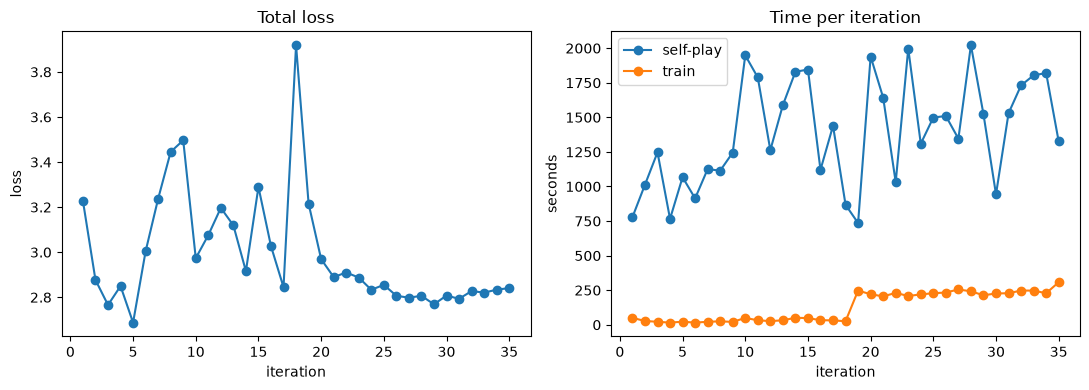

In [16]:
try:
    import pandas as pd
    df = pd.read_csv(ITER_CSV)
    display(df.tail(20))
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ax[0].plot(df["iteration"], df["loss"], marker="o")
        ax[0].set(title="Total loss", xlabel="iteration", ylabel="loss")
        ax[1].plot(df["iteration"], df["selfplay_seconds"], marker="o", label="self-play")
        ax[1].plot(df["iteration"], df["train_seconds"], marker="o", label="train")
        ax[1].set(title="Time per iteration", xlabel="iteration", ylabel="seconds")
        ax[1].legend()
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("Plotting skipped:", e)
except FileNotFoundError:
    print("No iterations logged yet — run section 5 first.")